   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.6 MB/s eta 0:00:00
📁 Please upload your canteen_sales_dataset.csv file


Saving canteen_sales_dataset.csv to canteen_sales_dataset (1).csv

✅ Dataset loaded successfully!
📊 Number of records: 1000


,day,weather,food_item,price,previous_sales,exam_day,weekend,sales
0,Monday,Rainy,Sandwich,41,63,0,0,90
1,Monday,Sunny,Vada Pav,20,81,1,0,129
2,Tuesday,Rainy,Sandwich,47,90,0,0,95
3,Friday,Cloudy,Samosa,17,64,0,0,130
4,Wednesday,Cloudy,Dosa,46,85,0,0,91



✅ Dataset cleaned successfully!
Final dataset size: (1000, 8)


🤖 MACHINE LEARNING MODEL PERFORMANCE

📌 Mean Absolute Error : 9.10
📌 RMSE               : 11.67
📌 R² Score           : 0.80

✅ Random Forest model trained successfully!


📊 FEATURE IMPORTANCE


,Feature,Importance
3,price,0.432096
4,previous_sales,0.203861
1,weather_encoded,0.123180
6,weekend,0.111276
2,food_encoded,0.091991
0,day_encoded,0.020480
5,exam_day,0.017117


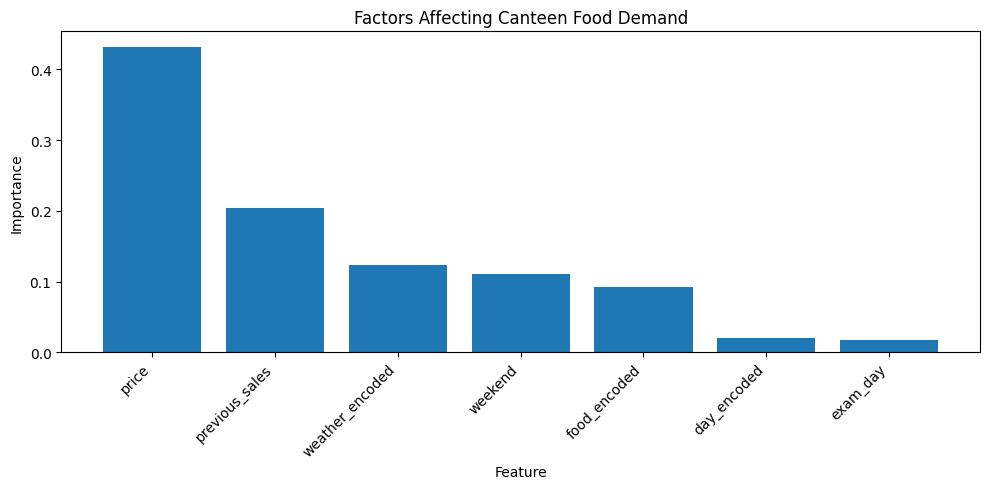



🍔 CANTEEN FOOD DEMAND PREDICTOR

Select tomorrow's conditions and click 'Predict Demand'.



✅ Interface ready!


In [2]:
# ================================================================
# 🍔 CANTEEN FOOD DEMAND PREDICTOR
# Optimized Google Colab Version
# Random Forest Regression + Interactive Interface
# ================================================================

# -----------------------------
# 1. INSTALL / IMPORT LIBRARIES
# -----------------------------

!pip -q install ipywidgets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ================================================================
# 2. LOAD DATASET
# ================================================================

# Upload the CSV file manually

from google.colab import files

print("📁 Please upload your canteen_sales_dataset.csv file")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\n✅ Dataset loaded successfully!")
print("📊 Number of records:", len(df))

display(df.head())


# ================================================================
# 3. CLEAN DATA
# ================================================================

# Remove unnecessary spaces from column names

df.columns = df.columns.str.strip()

# Remove duplicate rows

df = df.drop_duplicates()

# Remove rows containing missing values

df = df.dropna()

print("\n✅ Dataset cleaned successfully!")

print("Final dataset size:", df.shape)


# ================================================================
# 4. ENCODE CATEGORICAL FEATURES
# ================================================================

day_encoder = LabelEncoder()
weather_encoder = LabelEncoder()
food_encoder = LabelEncoder()

df["day_encoded"] = day_encoder.fit_transform(
    df["day"]
)

df["weather_encoded"] = weather_encoder.fit_transform(
    df["weather"]
)

df["food_encoded"] = food_encoder.fit_transform(
    df["food_item"]
)


# ================================================================
# 5. SELECT FEATURES
# ================================================================

features = [
    "day_encoded",
    "weather_encoded",
    "food_encoded",
    "price",
    "previous_sales",
    "exam_day",
    "weekend"
]

X = df[features]

y = df["sales"]


# ================================================================
# 6. TRAIN / TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ================================================================
# 7. TRAIN RANDOM FOREST MODEL
# ================================================================

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

model.fit(
    X_train,
    y_train
)


# ================================================================
# 8. MODEL EVALUATION
# ================================================================

predictions = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)


print("\n")
print("=" * 55)
print("🤖 MACHINE LEARNING MODEL PERFORMANCE")
print("=" * 55)

print(f"\n📌 Mean Absolute Error : {mae:.2f}")
print(f"📌 RMSE               : {rmse:.2f}")
print(f"📌 R² Score           : {r2:.2f}")

print("\n✅ Random Forest model trained successfully!")


# ================================================================
# 9. FEATURE IMPORTANCE
# ================================================================

importance = pd.DataFrame({

    "Feature": features,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\n")
print("=" * 55)
print("📊 FEATURE IMPORTANCE")
print("=" * 55)

display(importance)


# ================================================================
# 10. VISUALIZATION
# ================================================================

plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Factors Affecting Canteen Food Demand"
)

plt.xlabel("Feature")

plt.ylabel("Importance")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ================================================================
# 11. CREATE INTERACTIVE INTERFACE
# ================================================================

print("\n")
print("=" * 65)
print("🍔 CANTEEN FOOD DEMAND PREDICTOR")
print("=" * 65)

print(
    "\nSelect tomorrow's conditions and click "
    "'Predict Demand'."
)


# -----------------------------
# Dropdown: Day
# -----------------------------

day_dropdown = widgets.Dropdown(

    options=list(day_encoder.classes_),

    value="Monday",

    description="Day:",

    style={
        "description_width": "120px"
    },

    layout=widgets.Layout(
        width="400px"
    )
)


# -----------------------------
# Dropdown: Weather
# -----------------------------

weather_dropdown = widgets.Dropdown(

    options=list(weather_encoder.classes_),

    value="Sunny",

    description="Weather:",

    style={
        "description_width": "120px"
    },

    layout=widgets.Layout(
        width="400px"
    )
)


# -----------------------------
# Dropdown: Food
# -----------------------------

food_dropdown = widgets.Dropdown(

    options=list(food_encoder.classes_),

    value="Samosa",

    description="Food Item:",

    style={
        "description_width": "120px"
    },

    layout=widgets.Layout(
        width="400px"
    )
)


# -----------------------------
# Price input
# -----------------------------

price_input = widgets.FloatText(

    value=20,

    description="Price (₹):",

    style={
        "description_width": "120px"
    },

    layout=widgets.Layout(
        width="400px"
    )
)


# -----------------------------
# Previous sales
# -----------------------------

previous_sales_input = widgets.IntText(

    value=100,

    description="Previous Sales:",

    style={
        "description_width": "120px"
    },

    layout=widgets.Layout(
        width="400px"
    )
)


# -----------------------------
# Exam day
# -----------------------------

exam_dropdown = widgets.Dropdown(

    options=[
        ("No", 0),
        ("Yes", 1)
    ],

    value=0,

    description="Exam Day:",

    style={
        "description_width": "120px"
    },

    layout=widgets.Layout(
        width="400px"
    )
)


# -----------------------------
# Weekend
# -----------------------------

weekend_dropdown = widgets.Dropdown(

    options=[
        ("No", 0),
        ("Yes", 1)
    ],

    value=0,

    description="Weekend:",

    style={
        "description_width": "120px"
    },

    layout=widgets.Layout(
        width="400px"
    )
)


# ================================================================
# 12. PREDICTION BUTTON
# ================================================================

predict_button = widgets.Button(

    description="🍔  PREDICT DEMAND",

    button_style="success",

    layout=widgets.Layout(
        width="400px",
        height="45px"
    )
)


# ================================================================
# 13. OUTPUT AREA
# ================================================================

output = widgets.Output()


# ================================================================
# 14. PREDICTION FUNCTION
# ================================================================

def predict_demand(button):

    with output:

        clear_output()

        try:

            # Get selected values

            selected_day = day_dropdown.value

            selected_weather = weather_dropdown.value

            selected_food = food_dropdown.value

            selected_price = price_input.value

            selected_previous_sales = (
                previous_sales_input.value
            )

            selected_exam = exam_dropdown.value

            selected_weekend = weekend_dropdown.value


            # Validate inputs

            if selected_price <= 0:

                print(
                    "❌ Please enter a valid food price."
                )

                return


            if selected_previous_sales < 0:

                print(
                    "❌ Previous sales cannot be negative."
                )

                return


            # Encode categorical values

            day_value = day_encoder.transform(
                [selected_day]
            )[0]

            weather_value = weather_encoder.transform(
                [selected_weather]
            )[0]

            food_value = food_encoder.transform(
                [selected_food]
            )[0]


            # Create input dataframe

            input_data = pd.DataFrame({

                "day_encoded": [day_value],

                "weather_encoded": [weather_value],

                "food_encoded": [food_value],

                "price": [selected_price],

                "previous_sales": [
                    selected_previous_sales
                ],

                "exam_day": [
                    selected_exam
                ],

                "weekend": [
                    selected_weekend
                ]

            })


            # Make prediction

            prediction = model.predict(
                input_data
            )[0]


            prediction = max(
                0,
                round(prediction)
            )


            # Display result

            print("\n")
            print("╔" + "═" * 58 + "╗")

            print(
                "║"
                + "        🍔 CANTEEN DEMAND RESULT"
                .center(58)
                + "║"
            )

            print("╠" + "═" * 58 + "╣")

            print(
                f"║  Food Item       : {selected_food:<35}║"
            )

            print(
                f"║  Day             : {selected_day:<35}║"
            )

            print(
                f"║  Weather         : {selected_weather:<35}║"
            )

            print(
                f"║  Price           : ₹{selected_price:<34}║"
            )

            print(
                f"║  Previous Sales  : {selected_previous_sales:<35}║"
            )

            print("╠" + "═" * 58 + "╣")

            print(
                f"║  🎯 PREDICTED SALES: {prediction} plates"
                .ljust(59)
                + "║"
            )

            print("╠" + "═" * 58 + "╣")

            print(
                f"║  💡 Prepare approximately {prediction} plates."
                .ljust(59)
                + "║"
            )

            print("╚" + "═" * 58 + "╝")


        except Exception as error:

            print(
                "❌ Something went wrong:"
            )

            print(error)


# Connect button to function

predict_button.on_click(
    predict_demand
)


# ================================================================
# 15. DISPLAY INTERFACE
# ================================================================

display(
    widgets.VBox([

        day_dropdown,

        weather_dropdown,

        food_dropdown,

        price_input,

        previous_sales_input,

        exam_dropdown,

        weekend_dropdown,

        widgets.HTML("<br>"),

        predict_button,

        widgets.HTML("<br>"),

        output

    ])
)


print("\n✅ Interface ready!")